## 04 — Feature Importance: ML Techniques

Quantifies which features carry real predictive signal for `pitch_type` using two complementary approaches: correlation structure (to check redundancy within the `bat_*` block) and Mutual Information scoring (to compare compressed vs raw features).

**Sections:**
- Inter-stat correlation heatmap — mean absolute Pearson r across pitch types for every pair of `bat_*` stat families; reveals whether the 150-column block is effectively one signal or many
- PCA(5) loadings — what latent structure the principal components capture
- MI comparison — PC1–5 vs the top-10 individual `bat_*` features; settles whether compression unlocks collective signal that no single column carries alone

Run 02_data_quality and 03_pitch_distribution_eda first for context on data completeness and pitch mix intuition.

A high MI score means the feature (or component) reduces uncertainty about `pitch_type`. PCA loadings near ±1 on a stat family mean that family dominates the component; near 0 means it contributes little.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import pybaseball
from pybaseball import (
    cache,
    statcast,
    statcast_pitcher_pitch_arsenal,
    statcast_pitcher_arsenal_stats,
    statcast_batter_expected_stats,
    statcast_batter_pitch_arsenal,
)
from matplotlib.patches import Patch

sys.path.append(str(Path("..").resolve()))
from utils.features.feature_names import (
    TRAINABLE_COLUMNS,
    LABEL_COLUMN,
    STATCAST_PRE_PITCH,
    FANGRAPH_PRE_PITCH,
)

DATA_DIR = Path("..") / "data" / "cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache.config.cache_directory = str(DATA_DIR.resolve())
cache.config.save()
cache.enable()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

### Canonical pitch type codes (mirrors _PITCH_TYPES in feature_names.py)
PITCH_TYPES = ["FF", "SI", "FC", "SL", "CH", "CU", "FS", "KN", "ST", "SV"]

print("pybaseball :", pybaseball.__version__)
print("pandas     :", pd.__version__)
print("cache dir  :", cache.config.cache_directory)

pybaseball : 2.2.7
pandas     : 2.2.3
cache dir  : C:\Users\ihuang\Documents\python projects\MLB-Pitch-Predictor\data\cache


In [2]:
SEASON = 2024
PRIOR  = SEASON - 1

df = statcast("2024-06-01", "2024-06-30")
print(f"Raw Statcast shape: {df.shape}")

This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:00<00:00, 79.24it/s]


Raw Statcast shape: (116355, 118)


In [3]:
### Pitcher pitch-usage % (prior year)
pit_usage = statcast_pitcher_pitch_arsenal(PRIOR, arsenal_type="n_")
pit_usage_w = pit_usage.rename(columns={"pitcher_id": "pitcher"})  # col is already 'pitcher', no-op

### Pitcher per-pitch outcome stats (prior year)
pit_outcomes = statcast_pitcher_arsenal_stats(PRIOR, minPA=25)
pit_out_stat_cols = [
    c for c in pit_outcomes.columns
    if c not in ["last_name, first_name", "player_id", "team_name_alt", "pitch_type", "pitch_name"]
]
pit_outcomes_w = pit_outcomes.pivot_table(
    index="player_id", columns="pitch_type", values=pit_out_stat_cols, aggfunc="first"
)
pit_outcomes_w.columns = [f"{stat}_{pt}" for stat, pt in pit_outcomes_w.columns]
pit_outcomes_w = pit_outcomes_w.reset_index().rename(columns={"player_id": "pitcher"})

### Batter expected stats (prior year)
bat_xstats = statcast_batter_expected_stats(PRIOR)
bat_xstats_w = bat_xstats.rename(columns={"player_id": "batter"}).drop(
    columns=["last_name, first_name", "year"], errors="ignore"
)

### Batter vs pitch-type stats pivoted wide (prior year)
bat_vs_pitch = statcast_batter_pitch_arsenal(PRIOR, minPA=25)
bat_vs_stat_cols = [
    c for c in bat_vs_pitch.columns
    if c not in ["last_name, first_name", "player_id", "team_name_alt", "pitch_type", "pitch_name"]
]
bat_vs_pitch_w = bat_vs_pitch.pivot_table(
    index="player_id", columns="pitch_type", values=bat_vs_stat_cols, aggfunc="first"
)
bat_vs_pitch_w.columns = [f"bat_{stat}_{pt}" for stat, pt in bat_vs_pitch_w.columns]
bat_vs_pitch_w = bat_vs_pitch_w.reset_index().rename(columns={"player_id": "batter"})

### Merge all enrichment onto the pitch-level frame
df_enr = (
    df
    .merge(pit_usage_w,    on="pitcher", how="left", suffixes=("", "_pu"))
    .merge(pit_outcomes_w, on="pitcher", how="left", suffixes=("", "_po"))
    .merge(bat_xstats_w,   on="batter",  how="left", suffixes=("", "_bx"))
    .merge(bat_vs_pitch_w, on="batter",  how="left", suffixes=("", "_bv"))
)

print(f"Raw shape     : {df.shape}")
print(f"Enriched shape: {df_enr.shape}")
if "n_ff" in df_enr.columns:
    print(f"Pitcher arsenal coverage (n_ff non-null): {df_enr['n_ff'].notna().mean():.1%}")

Raw shape     : (116355, 118)
Enriched shape: (116355, 410)
Pitcher arsenal coverage (n_ff non-null): 75.0%


In [4]:
available    = [c for c in TRAINABLE_COLUMNS if c in df_enr.columns]
missing_cols = [c for c in TRAINABLE_COLUMNS if c not in df_enr.columns]

model_df = df_enr[available + [LABEL_COLUMN]].copy()
model_df = model_df[model_df[LABEL_COLUMN].isin(PITCH_TYPES)].reset_index(drop=True)

print(f"model_df shape          : {model_df.shape}")
print(f"TRAINABLE_COLUMNS total : {len(TRAINABLE_COLUMNS)}")
print(f"Found in enriched frame : {len(available)}")
if missing_cols:
    preview = missing_cols[:5]
    ellipsis = "..." if len(missing_cols) > 5 else ""
    print(f"Missing ({len(missing_cols)})            : {preview}{ellipsis}")
print(f"\nPitch type distribution:\n{model_df[LABEL_COLUMN].value_counts()}")

model_df shape          : (114080, 323)
TRAINABLE_COLUMNS total : 352
Found in enriched frame : 322
Missing (30)            : ['bat_run_value_per_100_KN', 'bat_run_value_per_100_SV', 'bat_run_value_KN', 'bat_run_value_SV', 'bat_pitches_KN']...

Pitch type distribution:
pitch_type
FF    37126
SI    18600
SL    16954
CH    11444
FC     9449
ST     8264
CU     7663
FS     3747
SV      563
KN      270
Name: count, dtype: int64


---
## Section 1 — bat_* Correlation and Joint Usefulness

The `bat_*` block contains 150 columns (`bat_{stat}_{pt}` for 15 stats × 10 pitch types). The hypothesis is that these features are **individually weak** predictors of pitch type — a batter's prior-year wOBA against fastballs doesn't directly tell a pitcher what to throw — but they might be **collectively useful** once compressed.

I try to answer whether all the stats measuring batter quality are useful or there is a lot of redundancy in information. PC loadings and MI comparison could reveal this. 

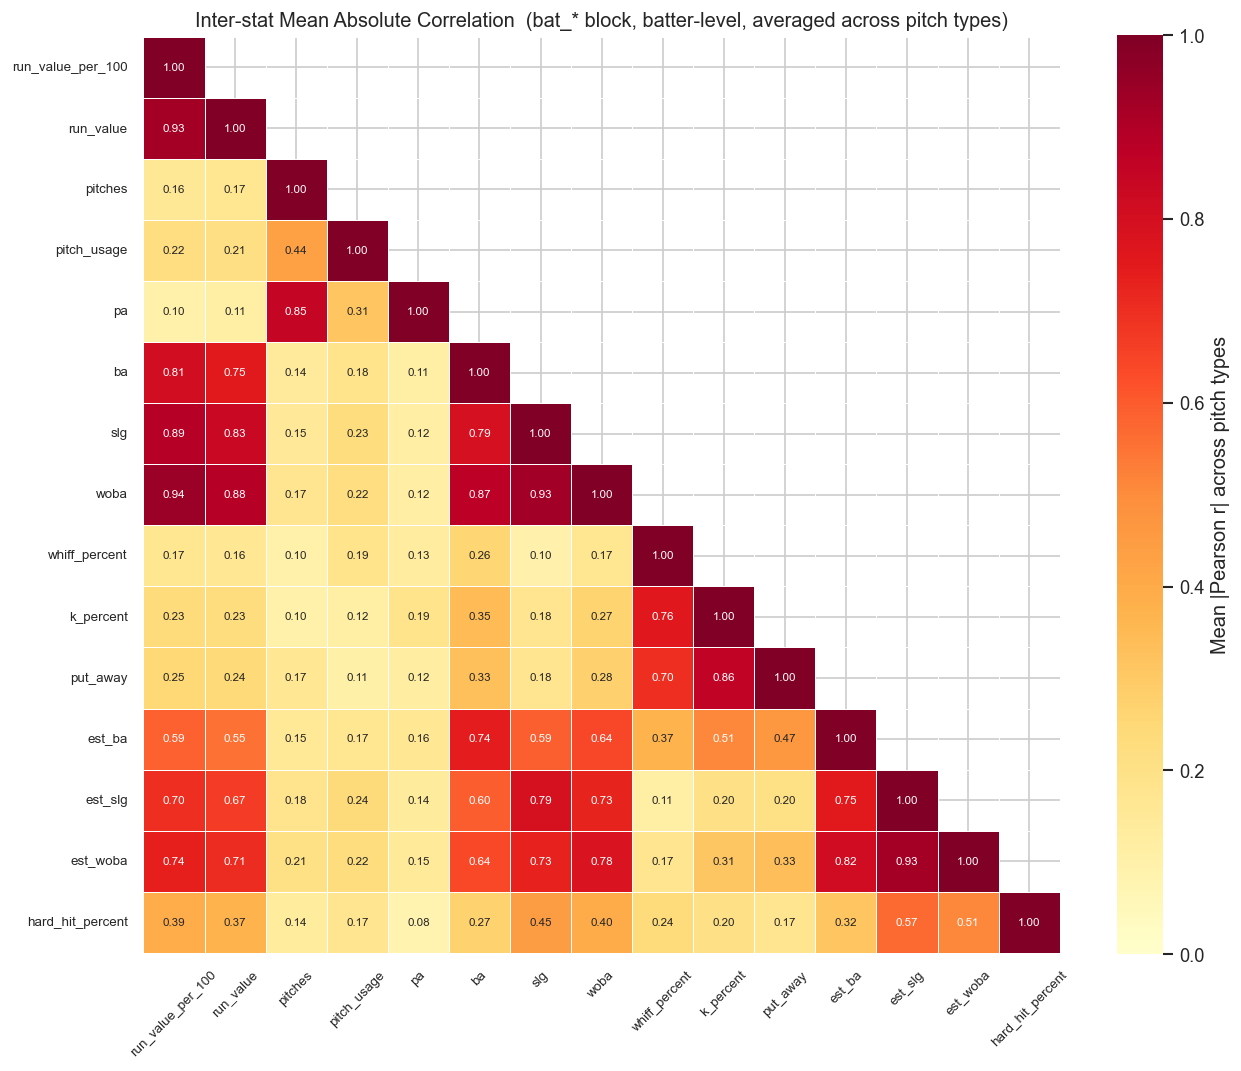

Mean off-diagonal |r|: 0.389  (low redundancy)


In [ ]:
### Visual 1 — 15×15 inter-stat mean absolute correlation heatmap

# For each pair of stat families (stat_i, stat_j), compute the mean absolute
# Pearson correlation across pitch types — using batter-deduplicated data so
# repeated appearances of the same batter don't inflate the correlations.

ARSENAL_STATS = [
    "run_value_per_100", "run_value", "pitches", "pitch_usage", "pa", "ba", "slg",
    "woba", "whiff_percent", "k_percent", "put_away", "est_ba", "est_slg", "est_woba",
    "hard_hit_percent",
]

bat_cols_avail = [c for c in available if c.startswith("bat_")]

### One row per batter — bat_* values are constant within a batter across pitches
bat_dedup = (
    model_df[["batter"] + bat_cols_avail]
    .drop_duplicates("batter")
    .set_index("batter")
)

inter_stat = np.full((len(ARSENAL_STATS), len(ARSENAL_STATS)), np.nan)

for i, stat_i in enumerate(ARSENAL_STATS):
    for j, stat_j in enumerate(ARSENAL_STATS):
        corrs = []
        for pt in PITCH_TYPES:
            col_i = f"bat_{stat_i}_{pt}"
            col_j = f"bat_{stat_j}_{pt}"
            if col_i in bat_dedup.columns and col_j in bat_dedup.columns:
                pair = bat_dedup[[col_i, col_j]].dropna()
                if len(pair) >= 5:
                    r = pair.iloc[:, 0].corr(pair.iloc[:, 1])
                    if not np.isnan(r):
                        corrs.append(abs(r))
        if corrs:
            inter_stat[i, j] = np.mean(corrs)

inter_stat_df = pd.DataFrame(inter_stat, index=ARSENAL_STATS, columns=ARSENAL_STATS)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(inter_stat_df, dtype=bool), k=1)  # hide upper triangle
sns.heatmap(
    inter_stat_df,
    ax=ax,
    mask=mask,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Mean |Pearson r| across pitch types"},
    square=True,
)
ax.set_title(
    "Inter-stat Mean Absolute Correlation  (bat_* block, batter-level, averaged across pitch types)",
    fontsize=12,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

mean_off_diag = inter_stat_df.values[~np.eye(len(ARSENAL_STATS), dtype=bool)].mean()
print(f"Mean off-diagonal |r|: {mean_off_diag:.3f}  "
      f"({'highly redundant' if mean_off_diag > 0.7 else 'moderate redundancy' if mean_off_diag > 0.4 else 'low redundancy'})")

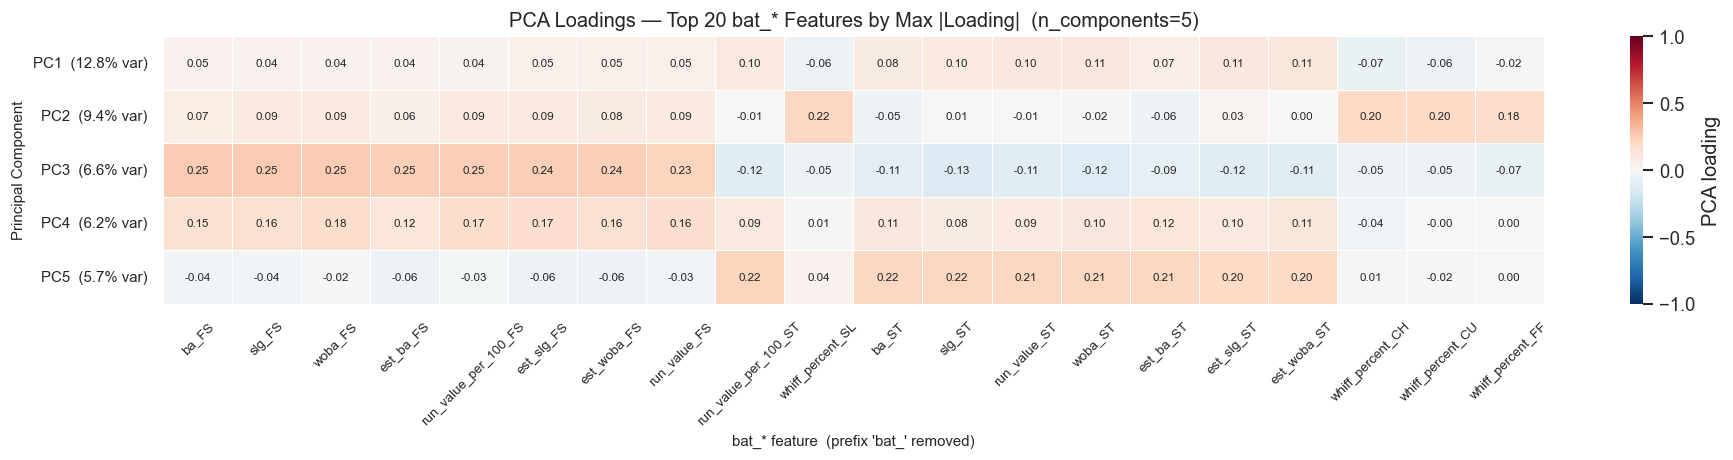

Cumulative variance explained:
  PC1–PC1: 12.8%
  PC1–PC2: 22.2%
  PC1–PC3: 28.8%
  PC1–PC4: 35.0%
  PC1–PC5: 40.8%


In [ ]:
### Visual 2 — PCA(5) loadings heatmap

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_bat        = imputer.fit_transform(model_df[bat_cols_avail])
X_bat_scaled = scaler.fit_transform(X_bat)

pca   = PCA(n_components=5, random_state=42)
X_pcs = pca.fit_transform(X_bat_scaled)   # shape (n_pitches, 5) — reused in cell 25

### PC row labels: include % variance explained
pc_labels = [
    f"PC{i+1}  ({var:.1%} var)"
    for i, var in enumerate(pca.explained_variance_ratio_)
]

loadings = pd.DataFrame(pca.components_, index=pc_labels, columns=bat_cols_avail)

### Select the top 20 features by maximum absolute loading across any PC
top20_feats = loadings.abs().max(axis=0).nlargest(20).index
loadings_top = loadings[top20_feats]

### Shorten column labels: drop "bat_" prefix for readability
short_labels = [c.replace("bat_", "") for c in top20_feats]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    loadings_top,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "PCA loading"},
    xticklabels=short_labels,
)
ax.set_title(
    "PCA Loadings — Top 20 bat_* Features by Max |Loading|  (n_components=5)",
    fontsize=12,
)
ax.set_xlabel("bat_* feature  (prefix 'bat_' removed)", fontsize=9)
ax.set_ylabel("Principal Component", fontsize=9)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

cum_var = pca.explained_variance_ratio_.cumsum()
print("Cumulative variance explained:")
for i, v in enumerate(cum_var):
    print(f"  PC1–PC{i+1}: {v:.1%}")

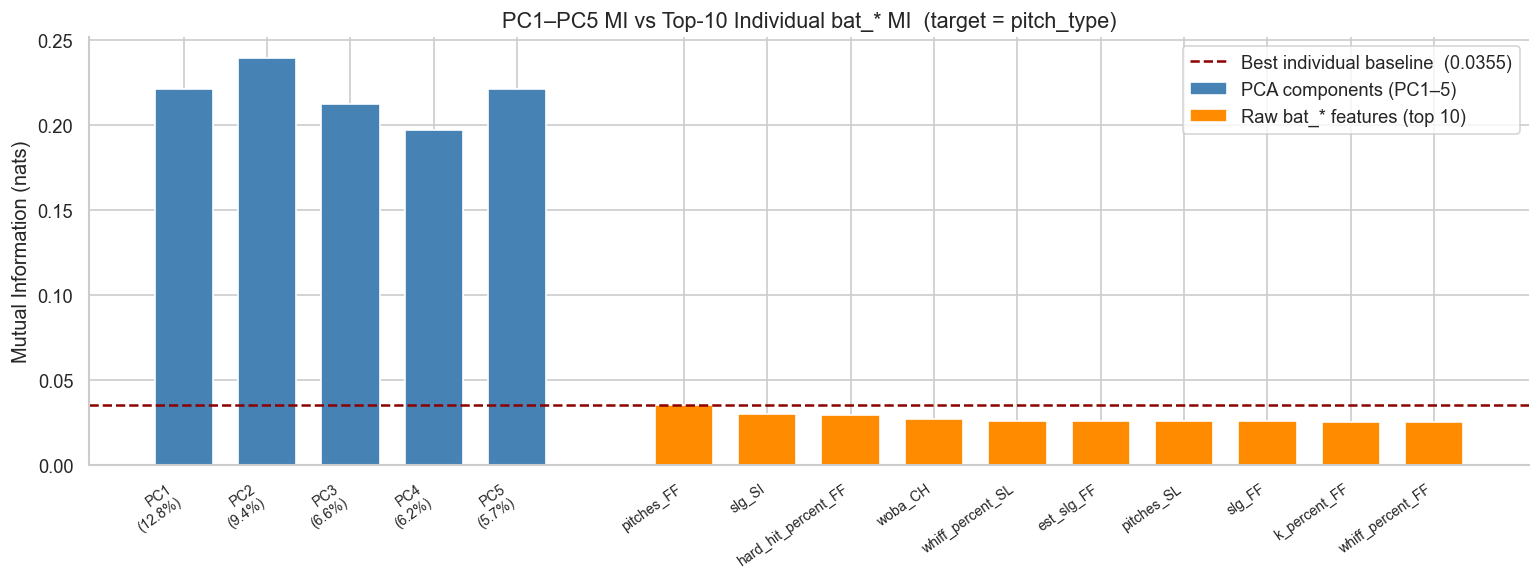


PC1 MI         : 0.2210
Best raw MI    : 0.0355  (bat_pitches_FF)

Verdict: PC1 clearly exceeds the best raw feature — bat_* features are JOINTLY USEFUL; use PCA-compressed columns.


In [ ]:
### Visual 3 — PC1–PC5 MI vs top-10 individual bat_* MI (baseline)

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

y = LabelEncoder().fit_transform(model_df[LABEL_COLUMN])

mi_pcs = mutual_info_classif(X_pcs,        y, discrete_features=False, random_state=42)
mi_raw = mutual_info_classif(X_bat_scaled, y, discrete_features=False, random_state=42)

mi_raw_series = pd.Series(mi_raw, index=bat_cols_avail).sort_values(ascending=False)
top10_raw     = mi_raw_series.head(10)
best_raw_mi   = top10_raw.max()

### Short PC labels (no variance in bar — use title row instead)
pc_bar_labels = [f"PC{i+1}\n({var:.1%})" for i, var in enumerate(pca.explained_variance_ratio_)]
raw_bar_labels = [c.replace("bat_", "") for c in top10_raw.index]

x_pc  = list(range(5))
x_raw = [i + 6 for i in range(10)] 

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x_pc,  mi_pcs,          color="steelblue",  width=0.7, edgecolor="white", label="PCA components (PC1–5)")
ax.bar(x_raw, top10_raw.values, color="darkorange", width=0.7, edgecolor="white", label="Raw bat_* features (top 10)")

ax.axhline(best_raw_mi, color="darkred", linestyle="--", linewidth=1.5,
           label=f"Best individual baseline  ({best_raw_mi:.4f})")

ax.set_xticks(x_pc + x_raw)
ax.set_xticklabels(pc_bar_labels + raw_bar_labels, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Mutual Information (nats)")
ax.set_title("PC1–PC5 MI vs Top-10 Individual bat_* MI  (target = pitch_type)", fontsize=13)
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

### Verdict
print(f"\nPC1 MI         : {mi_pcs[0]:.4f}")
print(f"Best raw MI    : {best_raw_mi:.4f}  ({top10_raw.idxmax()})")
if mi_pcs[0] > best_raw_mi * 1.10:
    verdict = "PC1 clearly exceeds the best raw feature — bat_* features are JOINTLY USEFUL; use PCA-compressed columns."
elif mi_pcs[0] > best_raw_mi:
    verdict = "PC1 slightly exceeds the best raw feature — marginal collective gain; worth investigating further."
else:
    verdict = "PC1 does not beat the best raw feature — bat_* features appear to carry no collective signal beyond individual features."
print(f"\nVerdict: {verdict}")